# Exploratory Data Analysis: Online Courses

This notebook profiles the course dataset, checks data quality, prepares analysis-only numeric fields, and explores the factors associated with course demand and pricing.

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
OUTPUT_DIR = Path("outputs/eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load the data

In [12]:
DATA_PATH = Path(r"D:\Recommder Systm\recommender-system\Data\data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH.resolve()}")

raw_df = pd.read_csv(DATA_PATH)
df = raw_df.copy()
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()

Rows: 5,027
Columns: 18


,course_name,instructor,course url,course image,course description,reviews_avg,reviews_count,course_duration,lectures_count,level,price_after_discount,main_price,course_flag,students_count,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,2022 Complete Python Bootcamp From Zero to Her...,Jose Portilla,https://www.udemy.com/course/complete-python-b...,https://img-b.udemycdn.com/course/240x135/5678...,Learn Python like a Professional Start from t...,Rating: 4.6 out of 5,440383 reviews,22 total hours,155 lectures,All Levels,Current price: E£319.99,"Original price: E£1,399.99",NaN,"1,629,692 students",NaN,NaN,NaN,NaN
1,The Web Developer Bootcamp 2022,Colt Steele,https://www.udemy.com/course/the-web-developer...,https://img-b.udemycdn.com/course/240x135/6252...,COMPLETELY REDONE - The only course you need t...,Rating: 4.7 out of 5,248508 reviews,64 total hours,615 lectures,All Levels,Current price: E£269.99,"Original price: E£1,399.99",NaN,"830,559 students",NaN,NaN,NaN,NaN
2,The Complete 2022 Web Development Bootcamp,Dr. Angela Yu,https://www.udemy.com/course/the-complete-web-...,https://img-b.udemycdn.com/course/240x135/1565...,Become a Full-Stack Web Developer with just ON...,Rating: 4.7 out of 5,234837 reviews,65.5 total hours,490 lectures,All Levels,Current price: E£349.99,"Original price: E£1,699.99",Bestseller,"794,897 students",NaN,NaN,NaN,NaN
3,Angular - The Complete Guide (2023 Edition),Maximilian Schwarzmüller,https://www.udemy.com/course/the-complete-guid...,https://img-b.udemycdn.com/course/240x135/7561...,"Master Angular 14 (formerly ""Angular 2"") and b...",Rating: 4.6 out of 5,174576 reviews,34.5 total hours,472 lectures,All Levels,Current price: E£319.99,"Original price: E£1,599.99",Bestseller,"634,196 students",NaN,NaN,NaN,NaN
4,Java Programming Masterclass covering Java 11 ...,"Tim Buchalka, Tim Buchalka's Learn Programming...",https://www.udemy.com/course/java-the-complete...,https://img-b.udemycdn.com/course/240x135/5336...,Learn Java In This Course And Become a Compute...,Rating: 4.5 out of 5,171838 reviews,80.5 total hours,401 lectures,All Levels,Current price: E£349.99,Original price: E£849.99,Bestseller,"727,934 students",NaN,NaN,NaN,NaN


## 2. Dataset overview and data quality

In [13]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "unique_values": df.nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)
overview

,dtype,non_null,missing,missing_pct,unique_values
Unnamed: 15,object,1,5026,99.98,1
Unnamed: 17,object,1,5026,99.98,1
Unnamed: 16,object,1,5026,99.98,1
Unnamed: 14,object,3,5024,99.94,3
course_flag,object,518,4509,89.70,3
main_price,object,4799,228,4.54,32
students_count,object,5013,14,0.28,4397
course_name,object,5013,14,0.28,4975
instructor,object,5016,11,0.22,2131
course description,object,5016,11,0.22,4967


Exact duplicate rows: 22
Duplicate percentage: 0.44%


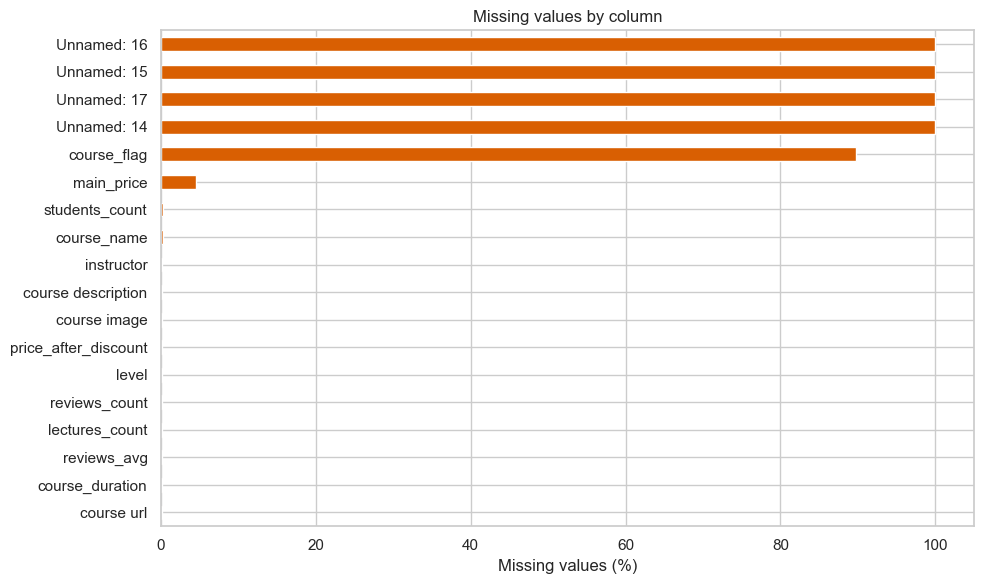

In [14]:
duplicate_count = df.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_count / len(df) * 100:.2f}%")

missing_plot = overview["missing_pct"].sort_values()
ax = missing_plot.plot(kind="barh", figsize=(10, 6), color="#d95f02")
ax.set_title("Missing values by column")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "missing_values.png", dpi=150)
plt.show()

## 3. Prepare an analysis dataframe

Columns that are at least 95% missing are excluded from the analysis dataframe. The raw dataframe remains unchanged. Numeric-looking text is converted by removing commas and extracting the first number.

In [15]:
high_missing_columns = df.columns[df.isna().mean().ge(0.95)].tolist()
analysis_df = df.drop(columns=high_missing_columns).drop_duplicates().copy()
print("Excluded columns:", high_missing_columns)
print(f"Analysis shape after duplicate removal: {analysis_df.shape}")

numeric_columns = [
    "reviews_avg", "reviews_count", "course_duration",
    "lectures_count", "price_after_discount", "main_price",
    "students_count",
]
for column in numeric_columns:
    analysis_df[column] = pd.to_numeric(
        analysis_df[column].astype(str).str.replace(",", "", regex=False)
        .str.extract(r"(\d+(?:\.\d+)?)", expand=False),
        errors="coerce",
    )

analysis_df[numeric_columns].describe().T

Excluded columns: ['Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17']
Analysis shape after duplicate removal: (5005, 14)


,count,mean,std,min,25%,50%,75%,max
reviews_avg,"5,000.00",4.43,6.52,1.70,4.10,4.40,4.60,399.99
reviews_count,"4,999.00","2,267.62","11,597.14",3.60,206.00,405.00,"1,129.00","440,383.00"
course_duration,"5,001.00",12.25,18.40,1.00,4.00,7.00,14.00,539.00
lectures_count,"4,989.00",94.41,97.41,1.50,36.00,63.00,113.00,800.00
price_after_discount,"5,000.00",268.66,125.57,40.00,229.99,269.99,269.99,"3,449.00"
main_price,"4,783.00",765.57,431.84,9.00,349.99,719.99,"1,199.99","1,699.99"
students_count,"4,997.00","23,214.09","59,685.66",269.99,"2,423.00","6,641.00","20,273.00","1,629,692.00"


## 4. Numeric distributions

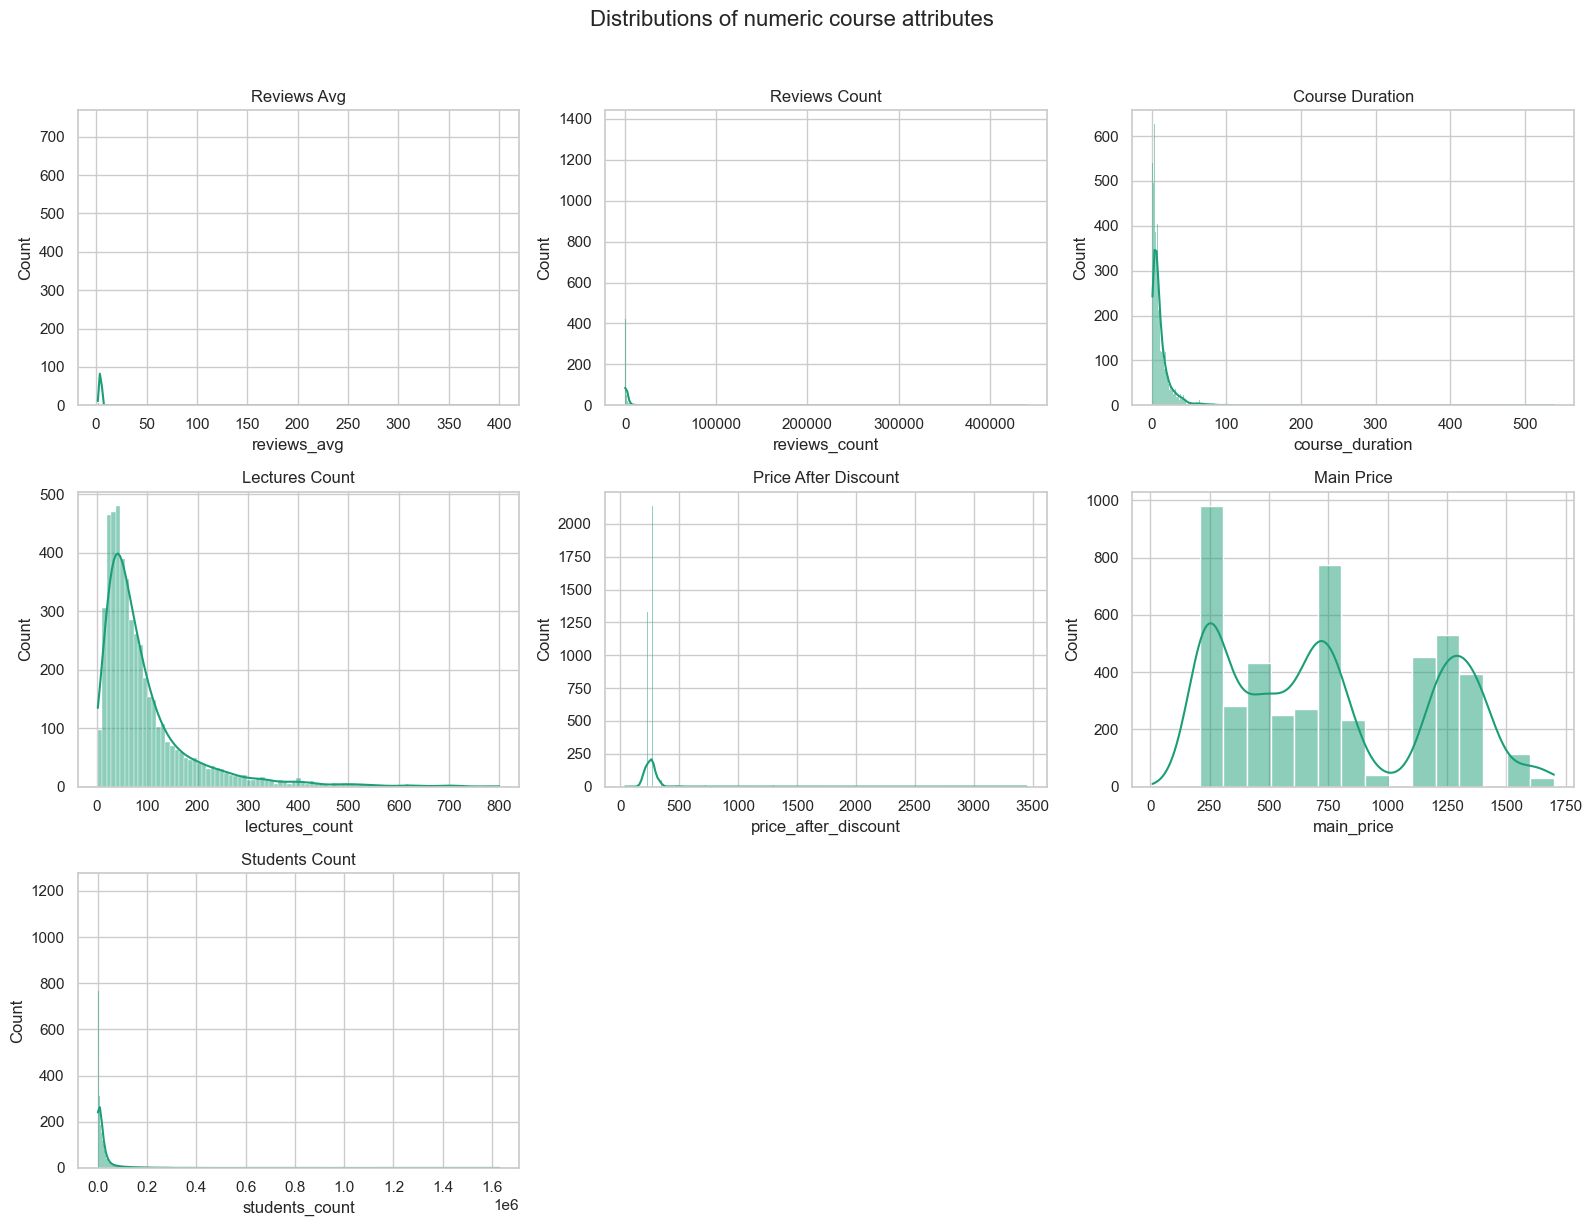

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()
for axis, column in zip(axes, numeric_columns):
    sns.histplot(data=analysis_df, x=column, kde=True, ax=axis, color="#1b9e77")
    axis.set_title(column.replace("_", " " ).title())
for axis in axes[len(numeric_columns):]:
    axis.set_visible(False)
fig.suptitle("Distributions of numeric course attributes", y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
summary = analysis_df[numeric_columns].describe().T
summary["missing"] = analysis_df[numeric_columns].isna().sum()
summary["skew"] = analysis_df[numeric_columns].skew()
summary.sort_values("skew", ascending=False)

,count,mean,std,min,25%,50%,75%,max,missing,skew
reviews_avg,"5,000.00",4.43,6.52,1.70,4.10,4.40,4.60,399.99,5,54.01
reviews_count,"4,999.00","2,267.62","11,597.14",3.60,206.00,405.00,"1,129.00","440,383.00",6,19.18
students_count,"4,997.00","23,214.09","59,685.66",269.99,"2,423.00","6,641.00","20,273.00","1,629,692.00",8,9.92
course_duration,"5,001.00",12.25,18.40,1.00,4.00,7.00,14.00,539.00,4,9.66
price_after_discount,"5,000.00",268.66,125.57,40.00,229.99,269.99,269.99,"3,449.00",5,9.58
lectures_count,"4,989.00",94.41,97.41,1.50,36.00,63.00,113.00,800.00,16,2.75
main_price,"4,783.00",765.57,431.84,9.00,349.99,719.99,"1,199.99","1,699.99",222,0.33


## 5. Categorical exploration

Course levels:


,course_count
level,
All Levels,2680
Beginner,1524
Intermediate,705
Expert,78
Current price: E£199.99,6
Missing,4
Current price: E£269.99,3
Current price: E£229.99,2
Rating: 4.5 out of 5,1


Top instructors by course count:


,course_count
instructor,
Packt Publishing,90
Bluelime Learning Solutions,73
Laurence Svekis,50
"Eduonix Learning Solutions, Eduonix-Tech .",47
Infinite Skills,32
Oak Academy,31
YouAccel Training,31
Loony Corn,30
Stephen Grider,29


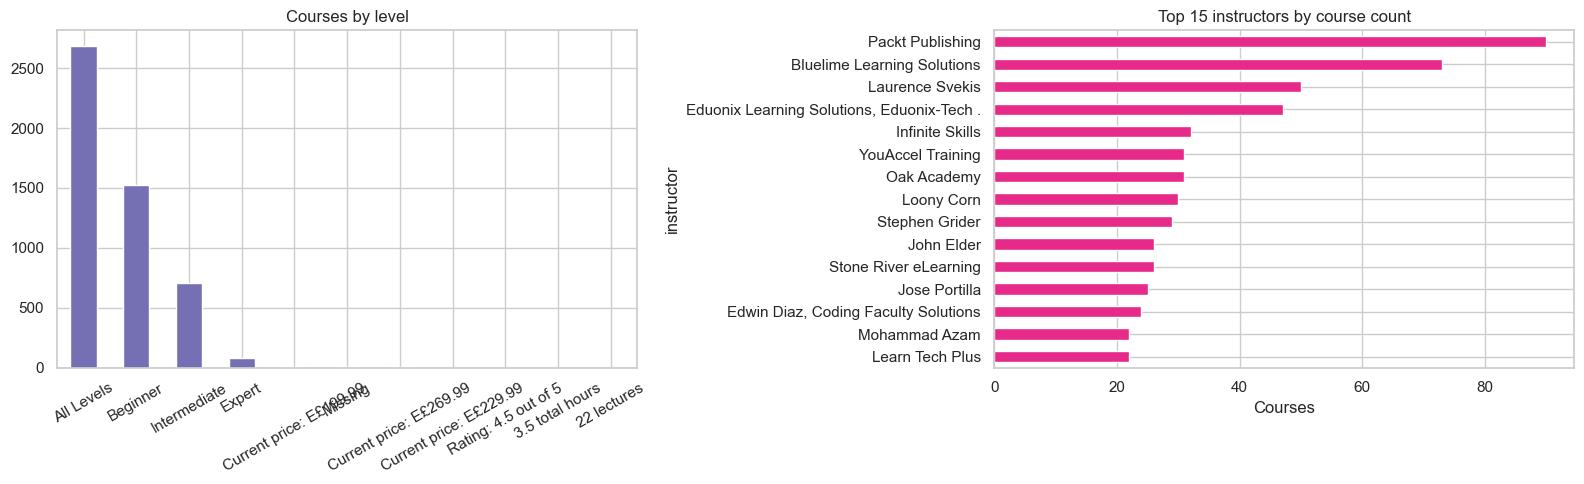

In [18]:
level_counts = analysis_df["level"].fillna("Missing").value_counts()
print("Course levels:")
display(level_counts.to_frame("course_count"))

top_instructors = analysis_df["instructor"].fillna("Missing").value_counts().head(15)
print("Top instructors by course count:")
display(top_instructors.to_frame("course_count"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
level_counts.plot(kind="bar", ax=axes[0], color="#7570b3")
axes[0].set_title("Courses by level")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
top_instructors.sort_values().plot(kind="barh", ax=axes[1], color="#e7298a")
axes[1].set_title("Top 15 instructors by course count")
axes[1].set_xlabel("Courses")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "categorical_overview.png", dpi=150)
plt.show()

## 6. Relationships and correlation

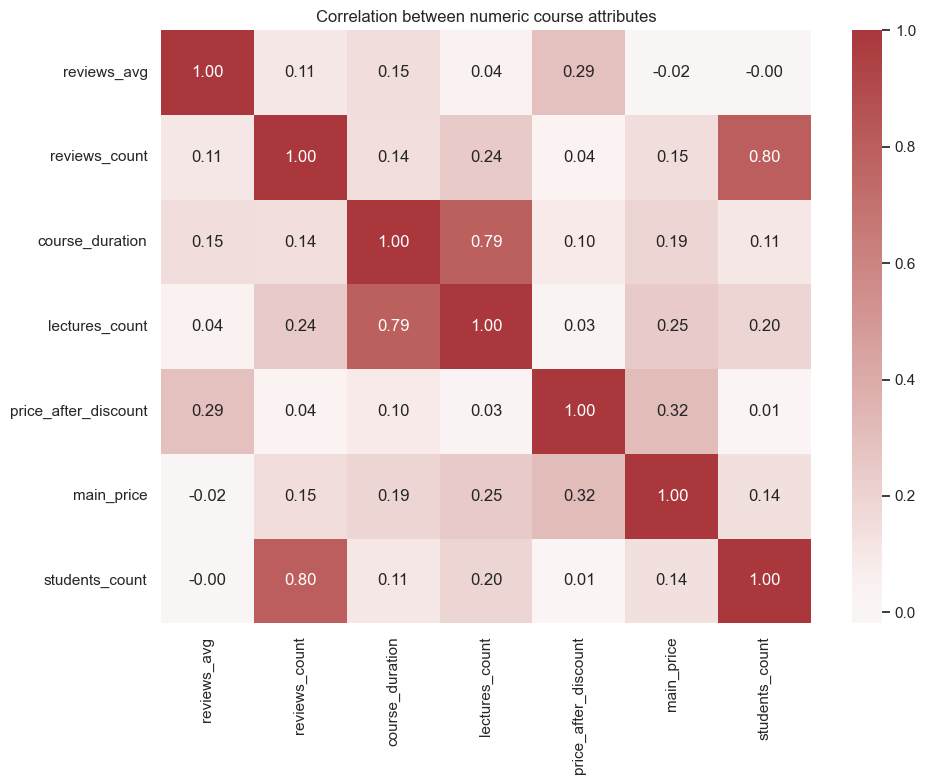

In [19]:
correlation = analysis_df[numeric_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation between numeric course attributes")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=150)
plt.show()

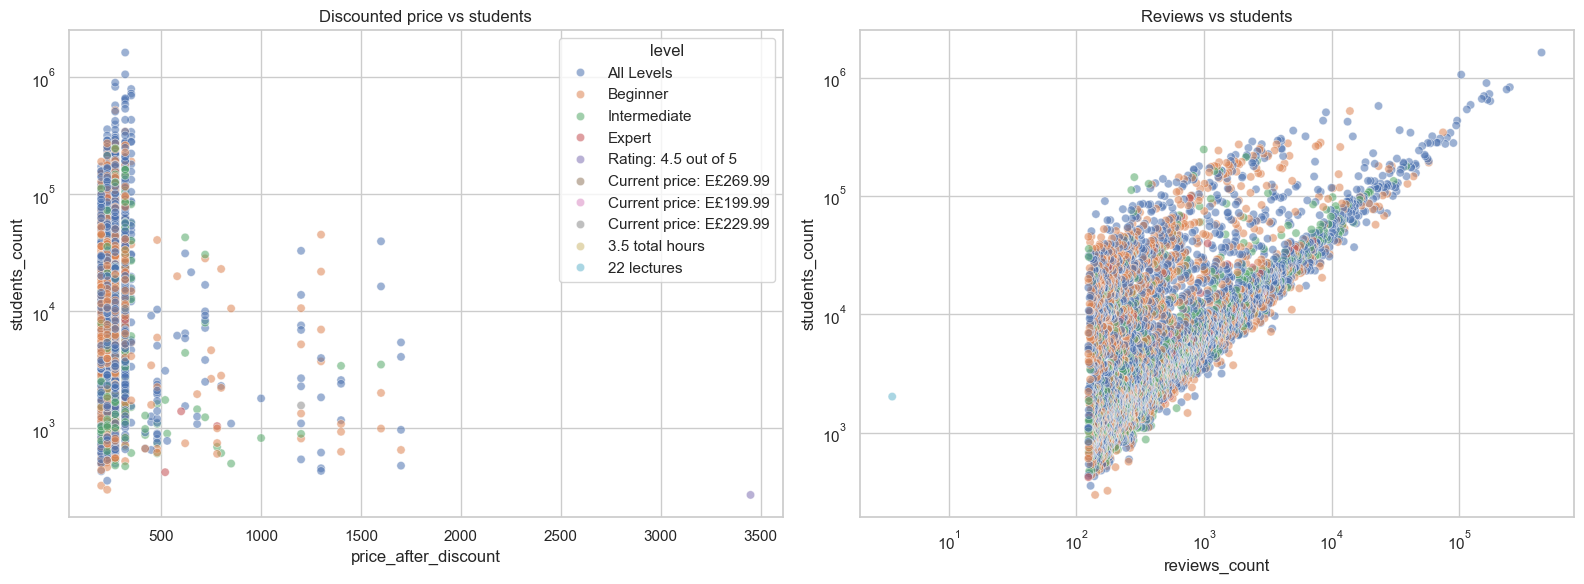

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=analysis_df, x="price_after_discount", y="students_count", hue="level", alpha=0.55, ax=axes[0])
axes[0].set_title("Discounted price vs students")
axes[0].set_yscale("log")
sns.scatterplot(data=analysis_df, x="reviews_count", y="students_count", hue="level", alpha=0.55, ax=axes[1], legend=False)
axes[1].set_title("Reviews vs students")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "demand_relationships.png", dpi=150)
plt.show()

## 7. Highest-demand courses

In [21]:
display_columns = [
    "course_name", "instructor", "level",
    "students_count", "reviews_count", "reviews_avg",
    "price_after_discount",
]
print("Top courses by student count")
display(analysis_df.nlargest(15, "students_count")[display_columns])

print("Top courses by review count")
display(analysis_df.nlargest(15, "reviews_count")[display_columns])

Top courses by student count


,course_name,instructor,level,students_count,reviews_count,reviews_avg,price_after_discount
0,2022 Complete Python Bootcamp From Zero to Her...,Jose Portilla,All Levels,"1,629,692.00","440,383.00",4.60,319.99
11,Automate the Boring Stuff with Python Programming,Al Sweigart,All Levels,"1,060,445.00","103,366.00",4.70,319.99
6,Machine Learning A-Z™: Hands-On Python & R In ...,"Kirill Eremenko, Hadelin de Ponteves, Ligency ...",All Levels,"900,823.00","163,104.00",4.50,269.99
1,The Web Developer Bootcamp 2022,Colt Steele,All Levels,"830,559.00","248,508.00",4.70,269.99
2,The Complete 2022 Web Development Bootcamp,Dr. Angela Yu,All Levels,"794,897.00","234,837.00",4.70,349.99
4,Java Programming Masterclass covering Java 11 ...,"Tim Buchalka, Tim Buchalka's Learn Programming...",All Levels,"727,934.00","171,838.00",4.50,349.99
7,The Complete JavaScript Course 2023: From Zero...,Jonas Schmedtmann,All Levels,"699,335.00","156,031.00",4.70,349.99
8,100 Days of Code: The Complete Python Pro Boot...,Dr. Angela Yu,All Levels,"662,274.00","150,024.00",4.70,319.99
5,"React - The Complete Guide (incl Hooks, React ...","Academind by Maximilian Schwarzmüller, Maximil...",All Levels,"649,985.00","166,128.00",4.60,319.99
3,Angular - The Complete Guide (2023 Edition),Maximilian Schwarzmüller,All Levels,"634,196.00","174,576.00",4.60,319.99


Top courses by review count


,course_name,instructor,level,students_count,reviews_count,reviews_avg,price_after_discount
0,2022 Complete Python Bootcamp From Zero to Her...,Jose Portilla,All Levels,"1,629,692.00","440,383.00",4.60,319.99
1,The Web Developer Bootcamp 2022,Colt Steele,All Levels,"830,559.00","248,508.00",4.70,269.99
2,The Complete 2022 Web Development Bootcamp,Dr. Angela Yu,All Levels,"794,897.00","234,837.00",4.70,349.99
3,Angular - The Complete Guide (2023 Edition),Maximilian Schwarzmüller,All Levels,"634,196.00","174,576.00",4.60,319.99
4,Java Programming Masterclass covering Java 11 ...,"Tim Buchalka, Tim Buchalka's Learn Programming...",All Levels,"727,934.00","171,838.00",4.50,349.99
5,"React - The Complete Guide (incl Hooks, React ...","Academind by Maximilian Schwarzmüller, Maximil...",All Levels,"649,985.00","166,128.00",4.60,319.99
6,Machine Learning A-Z™: Hands-On Python & R In ...,"Kirill Eremenko, Hadelin de Ponteves, Ligency ...",All Levels,"900,823.00","163,104.00",4.50,269.99
7,The Complete JavaScript Course 2023: From Zero...,Jonas Schmedtmann,All Levels,"699,335.00","156,031.00",4.70,349.99
8,100 Days of Code: The Complete Python Pro Boot...,Dr. Angela Yu,All Levels,"662,274.00","150,024.00",4.70,319.99
9,Python for Data Science and Machine Learning B...,Jose Portilla,All Levels,"588,524.00","122,487.00",4.60,319.99


## 8. Findings and limitations

Use the outputs above to record the strongest patterns observed in the data. Treat relationships as descriptive rather than causal: student counts and review counts may be highly skewed, missing values may not be random, and the dataset does not establish when courses were published or how long they were available.